# Adding contour to significant maps | brainspace:build_plotter

In [1]:
import os
from brainspace.plotting import plot_hemispheres
from brainspace.mesh.mesh_io import read_surface
from brainstat.datasets import fetch_mask, fetch_template_surface
from brainstat.stats.terms import MixedEffect, FixedEffect
from brainstat.stats.SLM import SLM

from osfclient import OSF
import tempfile
import pandas as pd
import numpy as np
import requests

In [2]:
def fetch_surface(surf_name='fsLR-5k.L.inflated.surf.gii', is_surf=True, nibabel=False):

        """
        Fetches a GIFTI surface file from the micapipe GitHub repository.

        Args:
            surf_name (str): The name of the surface file to download (default is 'fsLR-5k.L.inflated.surf.gii').

        Returns:
            nibabel.Giftidata: The loaded surface data from the GIFTI file.
        """

        # Construct the URL for the surface file on GitHub
        url = f'https://raw.githubusercontent.com/MICA-MNI/micapipe/refs/heads/master/surfaces/{surf_name}'

        # Step 1: Download the surface file from the URL
        response = requests.get(url)

        # Ensure the request was successful
        if response.status_code != 200:
            raise Exception(f"Failed to download the surface file: {surf_name} (Status code: {response.status_code})")

        # Step 2: Save the downloaded file in a temporary directory
        with tempfile.NamedTemporaryFile(delete=False, suffix='.surf.gii') as temp_file:
            temp_file.write(response.content)
            temp_file_name = temp_file.name  # Get the temporary file name

        # Step 3: Read the surface data from the downloaded file (assuming GIFTI format)
        if is_surf:
            if nibabel:
                surf_data = nib.load(temp_file_name)
            else:
                surf_data = read_surface(temp_file_name, itype='gii')
        else:
            surf_data = nib.load(temp_file_name).darrays[0].data

        # Step 4: Remove the temporary file after reading (to avoid cluttering disk)
        os.remove(temp_file_name)

        # Return the surface data
        return surf_data

def osf_download(name: str, project_id: str) -> str:
    """
    Download a file from an OSF project to a temporary location and return the file path.
    
    Parameters:
    - name (str): The name of the file to download.
    - project_id (str): The OSF project ID.
    
    Returns:
    - str: The path of the downloaded file.
    """
    # Initialize OSF client
    osf = OSF()

    # Retrieve the project
    project = osf.project(project_id)

    # Get the default storage (osfstorage)
    storage = project.storage('osfstorage')

    # List all files and filter by name
    file_ = next((f for f in storage.files if f.name == name), None)

    if file_:
        print(f"Found file: {file_.name}")
        
        # Create a temporary directory
        temp_dir = tempfile.mkdtemp()

        # Define the local path to store the file
        local_path = os.path.join(temp_dir, file_.name)

        # Download the file to the temporary directory
        with open(local_path, 'wb') as local_file:
            file_.write_to(local_file)
            print(f"Downloaded {file_.name} to {local_path}")

        # Return the path of the downloaded file
        return local_path
    else:
        raise FileNotFoundError(f"File '{name}' not found in the project.")


# FLIP data Right to Left
def flip_mat(mat_l, mat_r, lat_vec, flip='R'):
    '''
    Flips Right to Left data matrices to generate
    new matrices IPSILATERAL and CONTRALATERAL
    relative to the seizure onset

    Parameters
    ----------
    mat_l : numpy array
        Matrix with the values associated to the LEFT structures [subject x feature].
    mat_r     : numpy array
        Matrix with the values associated to the RIGHT structures [subject x feature].
    lat_vec   : numpy array (strings)
        Array with the laterality coded as R and L (rigth and left respectively).
    flip      : string
    Returns
    -------
    ipsi, ctra
    '''
    print("Flipping data from Right to Left")

    # Create an  array for the results
    ipsi = np.ndarray.copy(mat_l)
    ctra =  np.ndarray.copy(mat_r)

    for i, Lat in enumerate(lat_vec):
        if Lat == flip:
            ipsi[i,:] = mat_r[i,:]
            ctra[i,:] = mat_l[i,:]

    return ipsi, ctra

## Example data from 2025_in-vivo_tauPET-mk6240_TLE repository

In [3]:
osf_path="~/OSF_data_revision-2025"
save_fig=False

# Load the data frame
osf_df = osf_download("18F-MK6240_in-vivo_database.csv", project_id='ct3gw')
df = pd.read_csv(osf_df)

# Load processed 18F-MK6240 PET data | matrix:{vertices x subjects}
osf_pet_raw = osf_download("surf-fsLR-32k_desc-GroupData_smooth-10mm_pvc-probGM_ref-cerebellarGM_trc-18Fmk6240_pet.npy", project_id='ct3gw')
pet_raw = np.load(osf_pet_raw)

# Load fsLR-32 surface
fslr32k_lh = fetch_surface('fsLR-32k.L.surf.gii')
fslr32k_rh = fetch_surface('fsLR-32k.R.surf.gii')
fslr32k = fetch_template_surface("fslr32k", join=True)

# Load fsLR-32k middle wall mask
fslr32k_mask = fetch_mask("fslr32k")

def mem_groups(Data, df, Surf, Pcorr=["fdr", "rft"], Cthr=0.025, mask=None, mem=True, group=['Healthy', 'Patient']):
    '''
    Generate a mixed effects model of a Surface
    Contras: [TLE - Controls]

    Parameters
    ----------
    regex : str
        Regular expression with the path(s) to the data to be uploaded.

    Returns
    -------
    Array, pandas.Dataframe
     '''
    # -----------------------------------------------------------------------------
    # terms
    term_grp = FixedEffect(df['group'])
    term_age = FixedEffect(df['age'])
    term_sex = FixedEffect(df['sex'])
    term_subject = MixedEffect(df['participant_id'])

    # contrast  (Patient - Control)
    # 1: control, 2: patient
    contrast_grp = (df.group == group[1]).astype(int) - (df.group == group[0]).astype(int)

    # Model is is mixed Subject is set as random MIxed effect variable
    if mem == True:
        print("Y ~ group + age + sex + 1/subject")
        model = term_grp + term_sex + term_age  + term_subject
    else:
        model = term_grp + term_sex + term_age
        print("Y ~ group + age + sex")

    # fitting the model
    slm_mixed = SLM(
        model,
        contrast_grp,
        mask=mask,
        surf=Surf,
        correction=Pcorr,
        two_tailed=True,
        cluster_threshold=Cthr
    )
    slm_mixed.fit(Data)

    return slm_mixed

Found file: 18F-MK6240_in-vivo_database.csv


100%|████████████████████████████████████████████████████████████████████████████████| 48.9k/48.9k [00:00<00:00, 6.04Mbytes/s]


Downloaded 18F-MK6240_in-vivo_database.csv to /var/folders/yv/7rdtqnkn0mb58f5x_yprm2gw0000gn/T/tmp5naqm555/18F-MK6240_in-vivo_database.csv
Found file: surf-fsLR-32k_desc-GroupData_smooth-10mm_pvc-probGM_ref-cerebellarGM_trc-18Fmk6240_pet.npy


100%|████████████████████████████████████████████████████████████████████████████████| 39.5M/39.5M [00:05<00:00, 7.52Mbytes/s]


Downloaded surf-fsLR-32k_desc-GroupData_smooth-10mm_pvc-probGM_ref-cerebellarGM_trc-18Fmk6240_pet.npy to /var/folders/yv/7rdtqnkn0mb58f5x_yprm2gw0000gn/T/tmpk8pe3axe/surf-fsLR-32k_desc-GroupData_smooth-10mm_pvc-probGM_ref-cerebellarGM_trc-18Fmk6240_pet.npy


### Data management

In [4]:
# fsLR-32k length
n_64k = pet_raw.shape[1]
n_32k = int(n_64k/2)

# Calculate the zscore
hc = df['group'].values=="Healthy"
mu = np.nanmean(pet_raw[hc, :], axis=0)
sd = np.nanstd(pet_raw[hc, :], axis=0, ddof=1)
pet_z = (pet_raw - mu) / sd

# Flip R >> L 18F-mk6240 zscores
mkz_ipsi, mkz_contra = flip_mat(pet_z[:,0:n_32k], pet_z[:,n_32k:n_64k], df['lateralization'].values, flip='R')

# Merge ipsi and contra
tauMK6240z = np.concatenate((mkz_ipsi, mkz_contra), axis=1)


Flipping data from Right to Left


In [7]:
# CREATE the mixed effects model p> 0.01 (p>0.005 per tail) 
slm = mem_groups(Data=tauMK6240z, df=df, Surf=fslr32k, mask=fslr32k_mask, Cthr=0.025, mem=True,  Pcorr="rft")

# Create a tval map variable
mk6240_tval_map = slm.t[0]*fslr32k_mask

# Create the pval map
mk6240_pval_map = np.copy(slm.P["pval"]["C"])

# Create the binary pval map
mk6240_pval_map_bin = np.where(mk6240_pval_map > 0.025, 0, 1)


Y ~ group + age + sex + 1/subject


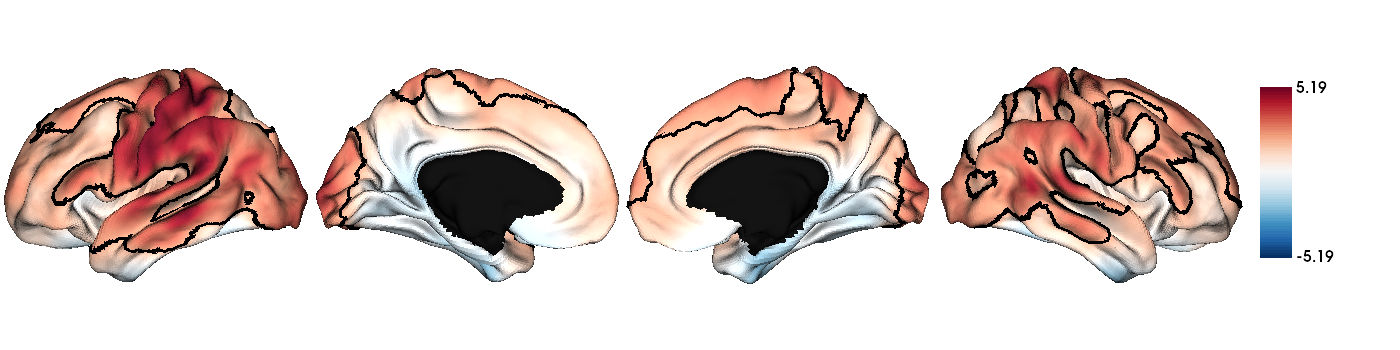

In [53]:
import numpy as np
import vtk

from vtk.util.numpy_support import numpy_to_vtk

from brainspace.plotting.surface_plotting import build_plotter


# -----------------------------------------------------------
# Create contour actor from binary significance map
# -----------------------------------------------------------
def make_contour_actor(
    surf,
    binary_map,
    color=(0, 0, 0),
    line_width=3
):

    poly = vtk.vtkPolyData()
    poly.DeepCopy(surf.VTKObject)

    vtk_sig = numpy_to_vtk(
        np.asarray(binary_map, dtype=np.float32),
        deep=True
    )

    vtk_sig.SetName("sig")

    poly.GetPointData().AddArray(vtk_sig)
    poly.GetPointData().SetActiveScalars("sig")

    contour = vtk.vtkContourFilter()
    contour.SetInputData(poly)
    contour.SetValue(0, 0.5)
    contour.Update()

    mapper = vtk.vtkPolyDataMapper()
    mapper.SetInputConnection(contour.GetOutputPort())
    mapper.ScalarVisibilityOff() 

    actor = vtk.vtkActor()
    actor.SetMapper(mapper)

    actor.GetProperty().SetColor(*color)
    actor.GetProperty().SetLineWidth(line_width)

    return actor


# -----------------------------------------------------------
# Split maps
# -----------------------------------------------------------
n_lh = fslr32k_lh.n_points

tval_lh = mk6240_tval_map[:n_lh]
tval_rh = mk6240_tval_map[n_lh:]

sig_lh = mk6240_pval_map_bin[:n_lh]
sig_rh = mk6240_pval_map_bin[n_lh:]


# -----------------------------------------------------------
# Attach quantitative map to surfaces
# -----------------------------------------------------------
array_name = "mk6240_t"

try:
    fslr32k_lh.remove_array(name=array_name, at="p")
except:
    pass

try:
    fslr32k_rh.remove_array(name=array_name, at="p")
except:
    pass

fslr32k_lh.append_array(
    tval_lh,
    name=array_name,
    at="p"
)

fslr32k_rh.append_array(
    tval_rh,
    name=array_name,
    at="p"
)


# -----------------------------------------------------------
# Build BrainSpace plotter
# Same layout used by plot_hemispheres(layout_style="row")
# -----------------------------------------------------------
surfs = {
    "lh": fslr32k_lh,
    "rh": fslr32k_rh
}

layout = [["lh", "lh", "rh", "rh"]]

views = [["lateral", "medial", "lateral", "medial"]]

plotter = build_plotter(
    surfs=surfs,
    layout=layout,
    array_name=[[array_name, array_name,
                 array_name, array_name]],
    view=views,
    color_bar="right",
    cmap="RdBu_r",
    color_range="sym",
    share="both",
    zoom=1.25,
    size=(1400, 350)
)


# -----------------------------------------------------------
# Create contour actors
# -----------------------------------------------------------
lwd=5
lcol=(0, 0, 0)

lh_med_contour = make_contour_actor(
    fslr32k_lh,
    sig_lh,
    color=lcol,
    line_width=lwd
)

lh_lat_contour = make_contour_actor(
    fslr32k_lh,
    sig_lh,
    color=lcol,
    line_width=lwd
)

rh_contour_lat = make_contour_actor(
    fslr32k_rh,
    sig_rh,
    color=lcol,
    line_width=lwd
)

rh_contour_med = make_contour_actor(
    fslr32k_rh,
    sig_rh,
    color=lcol,
    line_width=lwd
)


lh_med_contour.RotateZ(90)
lh_med_contour.RotateY(90)

lh_lat_contour.RotateZ(-90)
lh_lat_contour.RotateY(-90)

rh_contour_lat.RotateZ(90)
rh_contour_lat.RotateY(90)

rh_contour_med.RotateZ(-90)
rh_contour_med.RotateY(-90)


# -----------------------------------------------------------
# Add contours to all hemisphere renderers
#
# Renderer order:
# 0 = LH lateral
# 1 = LH medial
# 2 = RH lateral
# 3 = RH medial
# -----------------------------------------------------------
plotter.renderers[0][0].AddActor(lh_med_contour)
plotter.renderers[1][0].AddActor(lh_lat_contour)

plotter.renderers[2][0].AddActor(rh_contour_lat)
plotter.renderers[3][0].AddActor(rh_contour_med)


# -----------------------------------------------------------
# Show
# -----------------------------------------------------------
plotter.to_notebook()
